#### Homework 1,

**1. Turn today's script into a real reusable tool**

Right now the normal equation logic is just loose lines in a script. Wrap it into a small class:

In [1]:
import numpy as np
np.set_printoptions(precision=4, suppress=True)

class LinearRegressionScratch:
    def fit(self, X, y):
        # add bias column, compute w = (XᵀX)⁻¹Xᵀy, store self.w
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        XtX = X_b.T @ X_b
        Xty = X_b.T @ y
        self.w = np.linalg.inv(XtX) @ Xty
        return self

    def predict(self, X):
        # add bias column, return X_b @ self.w
        ones = np.ones((X.shape[0], 1))
        X_b = np.hstack([ones, X])
        return X_b @ self.w


In [2]:
# ---- Same houses dataset from Day 1 / Day 5 ----
# columns: size (sqft), bedrooms, age (years)
X = np.array([
    [1200, 3, 5],
    [800,  2, 10],
    [2000, 4, 2],
    [950,  2, 8]
], dtype=float)

y = np.array([140, 55, 240, 65], dtype=float)   # actual prices (₹ lakh)

# ---- Use the class ----
model = LinearRegressionScratch()
model.fit(X, y)

print("Learned weights [bias, w_size, w_bedrooms, w_age]:")
print(model.w)
print()

train_preds = model.predict(X)
print("Predictions on training data:", train_preds)
print("Actual training prices:      ", y)
print()

Learned weights [bias, w_size, w_bedrooms, w_age]:
[-83.1818   0.0455  58.8636  -1.5909]

Predictions on training data: [140.  55. 240.  65.]
Actual training prices:       [140.  55. 240.  65.]



In [3]:
# ---- Predict brand-new, unseen houses ----
new_houses = np.array([
    [1400, 3, 6],
    [700,  1, 15],
    [1800, 4, 1]
], dtype=float)

new_preds = model.predict(new_houses)
print("New unseen houses:\n", new_houses)
print("Predicted prices:", new_preds)

New unseen houses:
 [[1400.    3.    6.]
 [ 700.    1.   15.]
 [1800.    4.    1.]]
Predicted prices: [147.5    -16.3636 232.5   ]


#### Homework 2

2. Test it on a dataset you invent yourself

Make up a fresh 6–8 row dataset — different domain from houses (say, predicting a car's fuel efficiency from weight, horsepower, and age, or a student's exam score from study hours and sleep hours — your call). Fit your class, predict on 2 new unseen rows, sanity-check the sign of each weight makes real-world sense (like age being negative for house price did).

```
study_hours, sleep_hours, practice_tests  →  exam_score (out of 100)

Student 1:  2 hrs study, 5 hrs sleep, 1 practice test  →  42
Student 2:  4 hrs study, 6 hrs sleep, 2 practice tests →  55
Student 3:  6 hrs study, 7 hrs sleep, 2 practice tests →  68
Student 4:  8 hrs study, 6 hrs sleep, 3 practice tests →  78
Student 5:  3 hrs study, 4 hrs sleep, 1 practice test  →  45
Student 6:  5 hrs study, 8 hrs sleep, 3 practice tests →  72
Student 7:  7 hrs study, 5 hrs sleep, 4 practice tests →  75
```

```
New student A: 6 hrs study, 6 hrs sleep, 3 practice tests  → score = ?
New student B: 2 hrs study, 4 hrs sleep, 1 practice test   → score = ?
```

In [4]:
# ---- Student dataset: study_hours, sleep_hours, practice_tests -> exam_score ----
X = np.array([
    [2, 5, 1],
    [4, 6, 2],
    [6, 7, 2],
    [8, 6, 3],
    [3, 4, 1],
    [5, 8, 3],
    [7, 5, 4]
], dtype=float)

y = np.array([42, 55, 68, 78, 45, 72, 75], dtype=float)

In [5]:
model = LinearRegressionScratch()
model.fit(X, y)

print("Learned weights [bias, w_study, w_sleep, w_practice]:")
print(model.w)
print()

train_preds = model.predict(X)
sse = np.sum((y - train_preds)**2)

print("Prediction on training data:", train_preds)
print("Actual training scores:", y)
print("SSE on training data:", round(sse, 2))
print()

Learned weights [bias, w_study, w_sleep, w_practice]:
[16.5093  4.1612  2.6609  4.0435]

Prediction on training data: [42.1798 57.2065 68.1898 77.8947 43.68   70.733  75.116 ]
Actual training scores: [42. 55. 68. 78. 45. 72. 75.]
SSE on training data: 8.31



In [6]:
new_students = np.array([
    [6, 6, 3],   # Student A
    [2, 4, 1]    # Student B
], dtype=float)

new_preds = model.predict(new_students)
print("New unseen students: \n", new_students)
print("Predicted scores:", new_preds)

New unseen students: 
 [[6. 6. 3.]
 [2. 4. 1.]]
Predicted scores: [69.5723 39.5189]


#### Homework 3

**3. Add a real evaluation metric — R²**

SSE alone doesn't tell you if a model is good — 989 could be great or terrible depending on context. The standard fix:

```
SST = sum((actual - mean(actual))²)      # how much error a "just guess the average" model would have
R² = 1 - (SSE / SST)
```
Compute it by hand for your dataset. R² = 1 means perfect fit, R² = 0 means your model is no better than just guessing the average every time, negative means it's actively worse than that. This will matter a lot going forward — file it as your first "how good is my model, really" tool.

In [7]:
sse = np.sum((y - train_preds) ** 2)
sst = sum((y - np.mean(y))**2)

R_sq = 1 - (sse / sst)

print("SST:", sst)
print("R_sq:", R_sq)

SST: 1298.857142857143
R_sq: 0.9936026707358632


#### Homework 4

**4. Break it on purpose — multicollinearity**

Take your dataset and add a duplicate feature that's just a scaled copy of an existing one (e.g., if you have size_sqft, add size_sqm = size_sqft * 0.0929). Run the normal equation again.

* What happens to np.linalg.inv()? Does it error out, or silently give weird huge/unstable weights?
* This is Day 4's det(A) = 0 warning showing up for real, in a real ML context — two identical columns of information make XᵀX singular or nearly singular.
* Now try np.linalg.pinv() (pseudo-inverse) instead of np.linalg.inv(), or np.linalg.lstsq(X_b, y, rcond=None). Note what changes.

Write down, in your own words, what broke and why — that's the real deliverable here, not just running code.

In [23]:
X = np.array([
    [2, 5, 1],
    [4, 6, 2],
    [6, 7, 2],
    [8, 6, 3],
    [3, 4, 1],
    [5, 8, 3],
    [7, 5, 4]
], dtype=float)

study_minutes = X[:, 0] * 60
X = np.hstack([X, study_minutes.reshape(-1, 1)])   # shape (7, 4)

ones = np.ones((X.shape[0], 1))
X_b = np.hstack([ones, X])                          # shape (7, 5)
print("X_b shape (with bias column):", X_b.shape)

XtX = X_b.T @ X_b
XXt = X_b @ X_b.T
print("XᵀX shape:", XtX.shape,)# shape (5, 5) -- square!
print("XᵀX shape:", XXt.shape,)

y = np.array([42, 55, 68, 78, 45, 72, 75], dtype=float)

X_b shape (with bias column): (7, 5)
XᵀX shape: (5, 5)
XᵀX shape: (7, 7)


In [17]:
np.linalg.det(XtX)

np.float64(0.0)

In [25]:
try:
    det_result = np.linalg.det(XtX)
    print("Succeeded:", det_result)
except np.linalg.LinAlgError as e:
    print("FAILED as expected:", e)

Succeeded (unexpected!): 0.0


In [24]:
try:
    inv_result = np.linalg.inv(XtX)
    print("Succeeded (unexpected!):", inv_result)
except np.linalg.LinAlgError as e:
    print("FAILED as expected:", e)

FAILED as expected: Singular matrix


In [20]:
w = np.linalg.pinv(XtX) @ (X_b.T @ y)
w

array([16.5093,  0.0012,  2.6609,  4.0435,  0.0693])

In [26]:
w_lstsq, *_ = np.linalg.lstsq(X_b, y, rcond=None)

**R²**
```
SST = Σ(actual − mean)²        → total variation in y
SSE = Σ(actual − predicted)²   → variation your model failed to explain
R²  = 1 − SSE/SST
```
That leftover chunk has a name: SSR — Sum of Squares Regression (or "explained variation"). So the full picture is:
```
SST  =  SSR        +  SSE
(total)  (explained)   (unexplained)
```
```
R² = 1 − SSE/SST  =  (SST − SSE)/SST  =  SSR/SST
```

R² is literally: "what fraction of the total variance did my model manage to explain?"

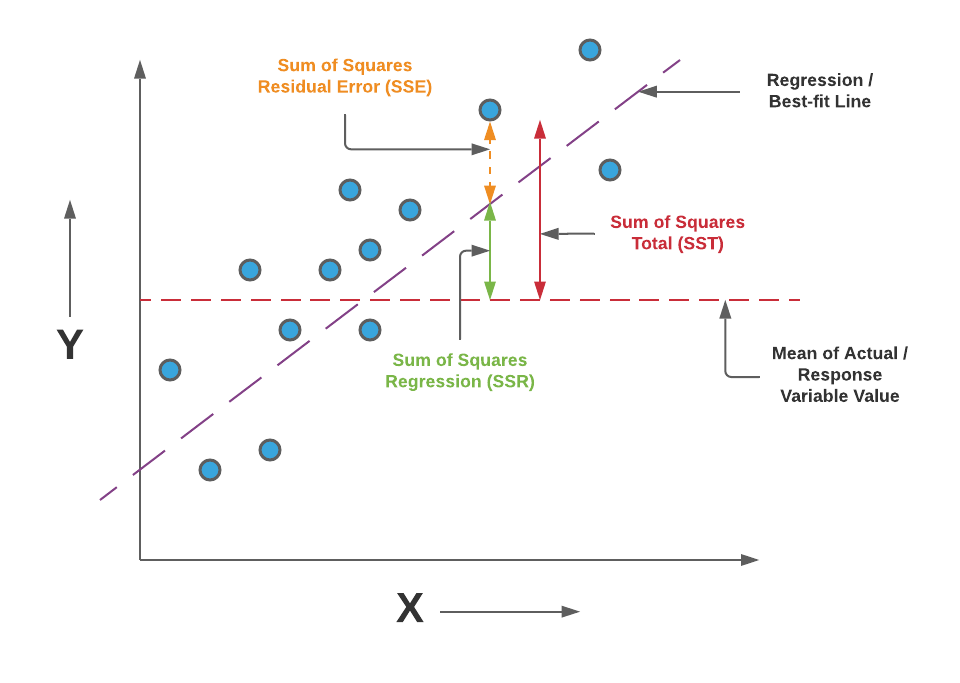
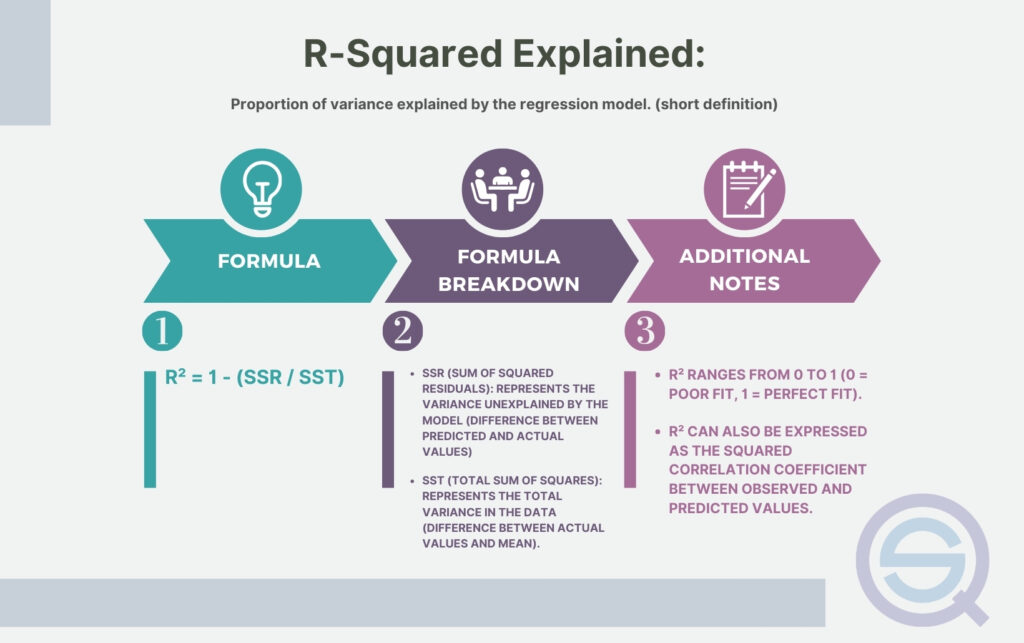

